In [ ]:
#complete case analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data_science_job.csv')

In [ ]:
df.shape

(19158, 13)

In [7]:
df.isnull().mean()*100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [10]:
col = [var for var in df.columns if df[var].isnull().mean() < 0.05 and df[var].isnull().mean() > 0]
df[col]

,city_development_index,enrolled_university,education_level,experience,training_hours
0,0.920,no_enrollment,Graduate,20.0,36.0
1,0.776,no_enrollment,Graduate,15.0,47.0
2,0.624,Full time course,Graduate,5.0,83.0
3,0.789,NaN,Graduate,0.0,52.0
4,0.767,no_enrollment,Masters,20.0,8.0
...,...,...,...,...,...
19153,0.878,no_enrollment,Graduate,14.0,42.0
19154,0.920,no_enrollment,Graduate,14.0,52.0
19155,0.920,no_enrollment,Graduate,20.0,44.0
19156,0.802,no_enrollment,High School,0.0,97.0


In [12]:
len(df[col].dropna() ) / len(df)

0.8968577095730244

In [14]:
new_df = df[col].dropna()
new_df.shape , df.shape

((17182, 5), (19158, 13))

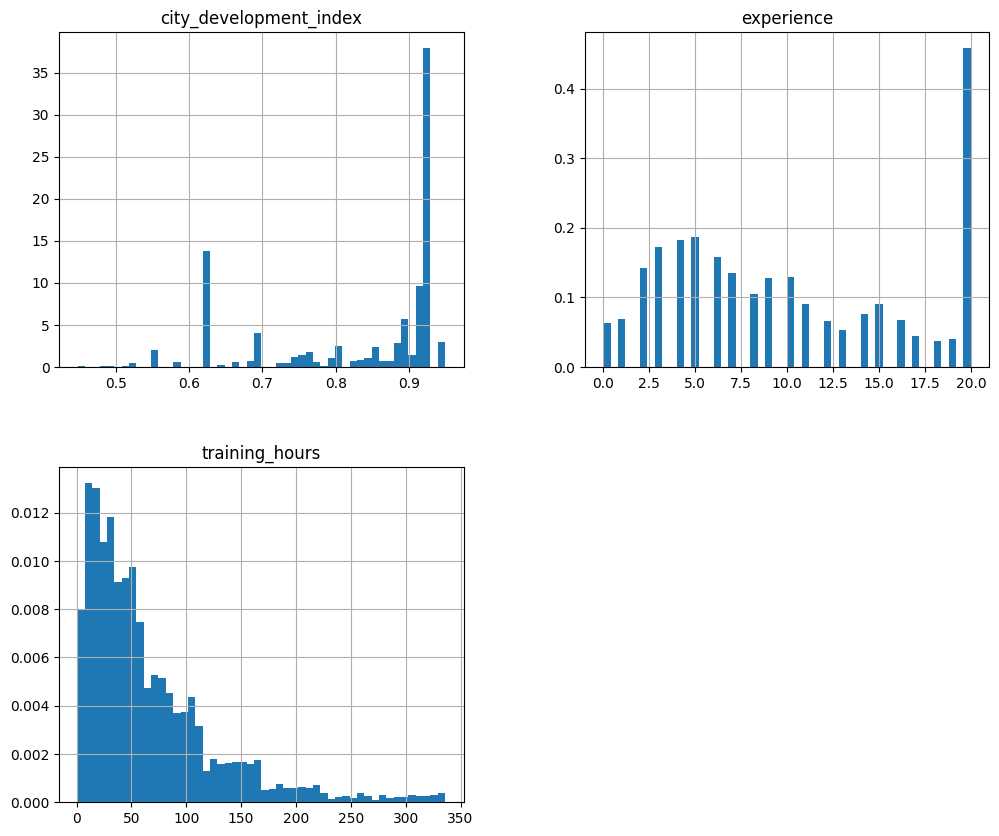

In [17]:
new_df.hist(bins=50 , density = True , figsize=(12,10))
plt.show()

<Axes: >

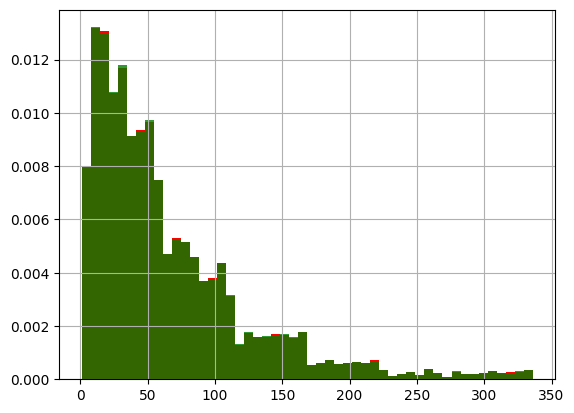

In [23]:
fig = plt.figure()
ax = fig.add_subplot(111)

df['training_hours'].hist(bins=50 , ax= ax, density = True, color = 'red')

new_df['training_hours'].hist(bins=50 , ax=ax, density = True, color = 'green',alpha = 0.8)

In [32]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df) , 
    new_df['enrolled_university'].value_counts() / len(new_df)
],axis=1)
temp.columns = ['original' , 'cca']
temp = temp.reset_index()
temp

,enrolled_university,original,cca
0,no_enrollment,0.721213,0.735188
1,Full time course,0.196106,0.200733
2,Part time course,0.062533,0.064079
